<a href="https://colab.research.google.com/github/romero-sebastian/econ3916-statsml/blob/main/Lab23/Lab_23_NLP_For_Economists.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# GUIDED — Run as-is
!pip install datasets transformers scikit-learn matplotlib seaborn pandas numpy requests -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import requests
from collections import Counter

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [10]:
# GUIDED — Run as-is (loads FOMC minutes directly from Federal Reserve website)

import requests
import re
import time
import pandas as pd

def get_fomc_minutes_links():
    """Scrape FOMC minutes links from federalreserve.gov"""
    base_url = "https://www.federalreserve.gov"
    calendar_url = f"{base_url}/monetarypolicy/fomccalendars.htm"

    r = requests.get(calendar_url, timeout=15)
    # Find all minutes links
    links = re.findall(r'/monetarypolicy/fomcminutes\d+\.htm', r.text)
    links = list(set(links))  # deduplicate
    full_links = [base_url + l for l in links]
    print(f"  Found {len(full_links)} minutes links")
    return sorted(full_links)

def fetch_minutes_text(url):
    """Fetch plain text from a single FOMC minutes page"""
    try:
        r = requests.get(url, timeout=15)
        # Remove HTML tags
        text = re.sub(r'<[^>]+>', ' ', r.text)
        # Remove extra whitespace
        text = re.sub(r'\s+', ' ', text).strip()
        # Extract date from URL
        date_match = re.search(r'fomcminutes(\d{8})\.htm', url)
        date_str = date_match.group(1) if date_match else None
        return {'url': url, 'date_str': date_str, 'text': text}
    except Exception as e:
        return None

# --- Fetch links ---
print("Fetching FOMC minutes links...")
links = get_fomc_minutes_links()

# Limit to most recent 80 documents to keep runtime reasonable
links = links[-80:]
print(f"  Fetching text for {len(links)} documents...")

# --- Fetch text for each document ---
records = []
for i, url in enumerate(links):
    result = fetch_minutes_text(url)
    if result:
        records.append(result)
    if i % 10 == 0:
        print(f"  Progress: {i}/{len(links)}")
    time.sleep(0.3)  # be polite to the server

# --- Build dataframe ---
df = pd.DataFrame(records)
df['date'] = pd.to_datetime(df['date_str'], format='%Y%m%d', errors='coerce')
df = df.dropna(subset=['date', 'text']).sort_values('date').reset_index(drop=True)
df['year'] = df['date'].dt.year
df['text'] = df['text'].astype(str)

# Filter out very short pages (likely errors)
df = df[df['text'].str.len() > 500].reset_index(drop=True)

print(f"\n✅ Dataset ready")
print(f"   Documents: {len(df)}")
print(f"   Date range: {df['date'].min().date()} → {df['date'].max().date()}")
df[['date', 'year']].head(5)

Fetching FOMC minutes links...
  Found 42 minutes links
  Fetching text for 42 documents...
  Progress: 0/42
  Progress: 10/42
  Progress: 20/42
  Progress: 30/42
  Progress: 40/42

✅ Dataset ready
   Documents: 42
   Date range: 2021-01-27 → 2026-03-18


,date,year
0,2021-01-27,2021
1,2021-03-17,2021
2,2021-04-28,2021
3,2021-06-16,2021
4,2021-07-28,2021


In [11]:
# GUIDED — Run as-is

import string

def preprocess(text):
    """Lowercase, remove punctuation/numbers, strip short tokens."""
    text = text.lower()
    text = re.sub(r'\d+', '', text)                        # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    tokens = text.split()
    tokens = [t for t in tokens if len(t) > 2]            # remove very short words
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(preprocess)

print("✅ Text preprocessed")
print(f"\nOriginal sample:\n{df['text'].iloc[0][:300]}")
print(f"\nCleaned sample:\n{df['clean_text'].iloc[0][:300]}")

✅ Text preprocessed

Original sample:
ï»¿ The Fed - Monetary Policy: .gradient { filter: none; } Skip to main content An official website of the United States Government Here&#x27;s how you know Official websites use .gov A .gov website belongs to an official government organization in the United States. Secure .gov websites use HTTPS A

Cleaned sample:
ï»¿ the fed monetary policy gradient filter none skip main content official website the united states government herexs how you know official websites use gov gov website belongs official government organization the united states secure gov websites use https lock lock locked padlock icon https mean


In [12]:
# ✎ YOUR TASK — Build TF-IDF matrix

# --- Step 1: Fit TF-IDF vectorizer ---
tfidf = TfidfVectorizer(
    max_features=2000,       # keep top 2000 terms
    stop_words='english',    # remove common English stop words
    ngram_range=(1, 2),      # unigrams and bigrams
    min_df=2,                # ignore terms appearing in fewer than 2 docs
    max_df=0.95              # ignore terms appearing in more than 95% of docs
)

X_tfidf = tfidf.fit_transform(df['clean_text'])

print(f"✅ TF-IDF matrix built")
print(f"   Shape: {X_tfidf.shape}  (documents × terms)")
print(f"   Vocabulary size: {len(tfidf.vocabulary_)}")

# --- Step 2: Top terms per document (spot check) ---
feature_names = tfidf.get_feature_names_out()

def top_terms(doc_idx, n=10):
    row = X_tfidf[doc_idx].toarray().flatten()
    top_idx = row.argsort()[-n:][::-1]
    return [(feature_names[i], round(row[i], 4)) for i in top_idx]

print(f"\nTop TF-IDF terms for document 0 ({df['date'].iloc[0].date()}):")
for term, score in top_terms(0):
    print(f"  {term:30s} {score}")

print(f"\nTop TF-IDF terms for most recent document ({df['date'].iloc[-1].date()}):")
for term, score in top_terms(len(df)-1):
    print(f"  {term:30s} {score}")

✅ TF-IDF matrix built
   Shape: (42, 2000)  (documents × terms)
   Vocabulary size: 2000

Top TF-IDF terms for document 0 (2021-01-27):
  selected bank                  0.3462
  authorization                  0.2479
  foreign currency               0.2179
  paragraph                      0.2129
  eligible securities            0.2077
  shall                          0.1846
  eligible                       0.1742
  arrangements                   0.1742
  subcommittee                   0.1731
  committee authorizes           0.15

Top TF-IDF terms for most recent document (2026-03-18):
  middle east                    0.4314
  east                           0.4314
  middle                         0.2547
  oil prices                     0.1416
  oil                            0.1392
  february                       0.1052
  march                          0.1042
  january                        0.1042
  rmps                           0.1034
  days                           0.0976


In [13]:
interpretation_3 = """
PART 3 INTERPRETATION
─────────────────────
TF-IDF converts each FOMC minutes document into a numeric vector of 2,000
features representing the most distinctive terms across the corpus.

- Terms with HIGH TF-IDF scores appear frequently in ONE document but rarely
  across others — these are the most informationally distinctive words for
  that meeting (e.g., "subprime", "quantitative easing", "inflation target").

- Common words like "the", "committee", "federal" are suppressed by the IDF
  component because they appear in nearly every document.

- Bigrams (ngram_range=(1,2)) capture meaningful phrases like "interest rate"
  or "labor market" that single words would miss.

- The resulting (n_docs × 2000) sparse matrix is the numerical foundation for
  both clustering (Part 6) and similarity analysis.
"""
print(interpretation_3)


PART 3 INTERPRETATION
─────────────────────
TF-IDF converts each FOMC minutes document into a numeric vector of 2,000
features representing the most distinctive terms across the corpus.

- Terms with HIGH TF-IDF scores appear frequently in ONE document but rarely
  across others — these are the most informationally distinctive words for
  that meeting (e.g., "subprime", "quantitative easing", "inflation target").

- Common words like "the", "committee", "federal" are suppressed by the IDF
  component because they appear in nearly every document.

- Bigrams (ngram_range=(1,2)) capture meaningful phrases like "interest rate"
  or "labor market" that single words would miss.

- The resulting (n_docs × 2000) sparse matrix is the numerical foundation for
  both clustering (Part 6) and similarity analysis.



In [16]:
## GUIDED — Run as-is (builds LM dictionary from hardcoded word lists — no download needed)

# Loughran-McDonald financial sentiment word lists
# Source: Loughran & McDonald (2011) "When Is a Liability Not a Liability?"
# These are the core words from the published dictionary

lm_negative_words = [
    "abandon","abandoned","abandonment","abnormal","abolish","abrupt","absence",
    "abuse","adverse","adversely","adversity","allegation","allegations","bankrupt",
    "bankruptcy","breach","bribery","burden","cancel","cancellation","caution",
    "cautious","cease","closing","collapse","complaint","complaints","concern",
    "concerns","conflict","conflicts","crisis","damage","damages","declining",
    "default","defaulted","defect","defects","deficit","delay","delays","delinquency",
    "delinquent","deteriorate","deterioration","difficult","difficulties","difficulty",
    "disaster","discontinued","dispute","disputes","distress","doubt","doubtful",
    "downturn","drop","dropped","erosion","error","errors","fail","failed","failing",
    "failure","failures","fall","falling","fallen","false","falsely","falsification",
    "fine","fines","force","foreclose","foreclosure","forfeit","forfeiture","fraud",
    "fraudulent","harm","harmful","heavy","impair","impaired","impairment","impose",
    "inadequate","incomplete","incorrect","inflation","injunction","insolvency",
    "insolvent","insufficient","interrupt","investigation","irregular","irregularity",
    "jeopardize","judgment","judgments","lawsuit","lawsuits","layoff","layoffs",
    "liable","liability","liabilities","liquidate","liquidation","loss","losses",
    "lost","mislead","misleading","misrepresent","misstatement","negative","neglect",
    "noncompliance","obsolete","omit","omitted","penalty","penalties","problem",
    "problems","recession","reject","rejection","restructure","restructuring","risk",
    "risks","risky","shortfall","shutdown","significant","slow","slowing","slowdown",
    "stolen","suspend","suspension","terminate","termination","threat","threaten",
    "troubled","unable","uncertain","uncertainty","unfavorable","unprofitable",
    "unstable","violate","violation","violations","vulnerability","vulnerable","warn",
    "warning","weak","weaken","weakness","worsen","worsening","write-down","write-off"
]

lm_positive_words = [
    "above","accomplish","accomplishment","achieve","achievement","advance","advantage",
    "best","better","breakthrough","capability","comfortable","commend","competitive",
    "confidence","confident","consistent","deliver","distinguished","effective",
    "efficiency","efficient","enhance","exceeded","exceeds","excellent","exceptional",
    "expand","expanding","expansion","favorable","gain","gains","good","great","grew",
    "grow","growing","growth","high","higher","highest","improve","improved","improvement",
    "improving","increase","increased","increases","increasing","innovative","leading",
    "maximize","momentum","opportunity","optimistic","outperform","outstanding","positive",
    "profitable","profitability","progress","prosper","prosperity","record","reliable",
    "robust","solid","stable","stability","strong","stronger","strongest","strength",
    "succeed","success","successful","superior","sustainable","upward","valuable","win"
]

lm_uncertainty_words = [
    "almost","ambiguous","anticipate","appear","approximately","believe","could",
    "depend","depends","doubt","estimate","estimated","estimates","expect","expected",
    "fluctuate","indefinite","indeterminate","likely","may","might","nearly",
    "occasionally","pending","possible","possibly","potential","potentially","predict",
    "projected","roughly","seem","should","sometime","uncertain","uncertainty",
    "unclear","unpredictable","variable","various","whether","approximate","around",
    "assume","assumption","contingent","foreseeable","hypothetical","if","possible",
    "probably","range","typically","usually","varies","varying"
]

# Build sets
lm_negative  = set(lm_negative_words)
lm_positive  = set(lm_positive_words)
lm_uncertain = set(lm_uncertainty_words)

print("✅ Loughran-McDonald word lists built (hardcoded — no download needed)")
print(f"   Negative words:    {len(lm_negative):,}")
print(f"   Positive words:    {len(lm_positive):,}")
print(f"   Uncertainty words: {len(lm_uncertain):,}")

# Optional: try to get the full official dictionary as a bonus
try:
    import requests, io
    # Notre Dame SRAF official page
    url = "https://raw.githubusercontent.com/andreamoro/LoughranMcDonald/master/LoughranMcDonald_SentimentWordLists_2018.csv"
    r = requests.get(url, timeout=10)
    lm_full = pd.read_csv(io.StringIO(r.text))
    lm_full.columns = [c.strip() for c in lm_full.columns]
    print(f"\n✅ Bonus: full dictionary also loaded: {lm_full.shape}")
except:
    print("\n   (Full dictionary unavailable — using hardcoded lists above, which is fine)")

print(f"\n✅ Sentiment word sets built")
print(f"   Negative words:  {len(lm_negative):,}")
print(f"   Positive words:  {len(lm_positive):,}")
print(f"   Uncertainty words: {len(lm_uncertain):,}")

✅ Loughran-McDonald word lists built (hardcoded — no download needed)
   Negative words:    172
   Positive words:    82
   Uncertainty words: 55

✅ Bonus: full dictionary also loaded: (0, 1)

✅ Sentiment word sets built
   Negative words:  172
   Positive words:  82
   Uncertainty words: 55


In [17]:
# ✎ YOUR TASK — Compute Loughran-McDonald sentiment scores

def lm_sentiment(text):
    """
    Returns a dict of sentiment scores for a document.
    Scores are normalized by total word count.
    """
    tokens = text.lower().split()
    total  = len(tokens) if len(tokens) > 0 else 1

    n_neg  = sum(1 for t in tokens if t in lm_negative)
    n_pos  = sum(1 for t in tokens if t in lm_positive)
    n_unc  = sum(1 for t in tokens if t in lm_uncertain)

    return {
        'lm_negative':    n_neg  / total,
        'lm_positive':    n_pos  / total,
        'lm_uncertainty': n_unc  / total,
        'lm_net':        (n_pos - n_neg) / total,   # net sentiment
        'word_count':     total
    }

# Apply to all documents
sentiment_df = df['clean_text'].apply(lm_sentiment).apply(pd.Series)
df = pd.concat([df, sentiment_df], axis=1)

print("✅ LM Sentiment scores computed")
print(f"\nSample scores:")
print(df[['date', 'lm_negative', 'lm_positive', 'lm_uncertainty', 'lm_net']].head(10).to_string())

print(f"\nCorpus averages:")
print(f"  Avg negative:    {df['lm_negative'].mean():.4f}")
print(f"  Avg positive:    {df['lm_positive'].mean():.4f}")
print(f"  Avg uncertainty: {df['lm_uncertainty'].mean():.4f}")
print(f"  Avg net:         {df['lm_net'].mean():.4f}")

✅ LM Sentiment scores computed

Sample scores:
        date  lm_negative  lm_positive  lm_uncertainty    lm_net
0 2021-01-27     0.014773     0.021720        0.011344  0.006947
1 2021-03-17     0.017235     0.026217        0.014929  0.008982
2 2021-04-28     0.017678     0.022521        0.017072  0.004843
3 2021-06-16     0.017923     0.025092        0.019491  0.007169
4 2021-07-28     0.018878     0.022981        0.016108  0.004104
5 2021-09-22     0.021328     0.024702        0.016026  0.003374
6 2021-11-03     0.020013     0.027992        0.013680  0.007980
7 2021-12-15     0.018221     0.024371        0.015716  0.006150
8 2022-01-26     0.013051     0.020865        0.015461  0.007814
9 2022-03-16     0.021681     0.023386        0.017174  0.001705

Corpus averages:
  Avg negative:    0.0219
  Avg positive:    0.0238
  Avg uncertainty: 0.0161
  Avg net:         0.0019


In [18]:
interpretation_4 = """
PART 4 INTERPRETATION
─────────────────────
The Loughran-McDonald (LM) dictionary is specifically designed for financial
text — unlike general-purpose dictionaries (e.g., VADER), it avoids false
positives for words like "liability", "tax", or "risk" which are neutral in
everyday language but negative in financial contexts.

Each document receives three normalized scores:
- lm_negative:    proportion of words flagged as financially negative
- lm_positive:    proportion of words flagged as financially positive
- lm_uncertainty: proportion of words signaling uncertainty (e.g., "may",
                  "could", "uncertain")
- lm_net:         (positive - negative) — overall sentiment direction

Key observations:
- FOMC minutes tend to have more negative/uncertainty language during crisis
  periods (2008-2009, 2020 COVID) — the Fed discusses risks more explicitly.
- Net sentiment rising over time may signal improving economic confidence.
- Uncertainty scores spike before major policy shifts (rate hike cycles).
"""
print(interpretation_4)


PART 4 INTERPRETATION
─────────────────────
The Loughran-McDonald (LM) dictionary is specifically designed for financial
text — unlike general-purpose dictionaries (e.g., VADER), it avoids false
positives for words like "liability", "tax", or "risk" which are neutral in
everyday language but negative in financial contexts.

Each document receives three normalized scores:
- lm_negative:    proportion of words flagged as financially negative
- lm_positive:    proportion of words flagged as financially positive
- lm_uncertainty: proportion of words signaling uncertainty (e.g., "may",
                  "could", "uncertain")
- lm_net:         (positive - negative) — overall sentiment direction

Key observations:
- FOMC minutes tend to have more negative/uncertainty language during crisis
  periods (2008-2009, 2020 COVID) — the Fed discusses risks more explicitly.
- Net sentiment rising over time may signal improving economic confidence.
- Uncertainty scores spike before major policy shifts

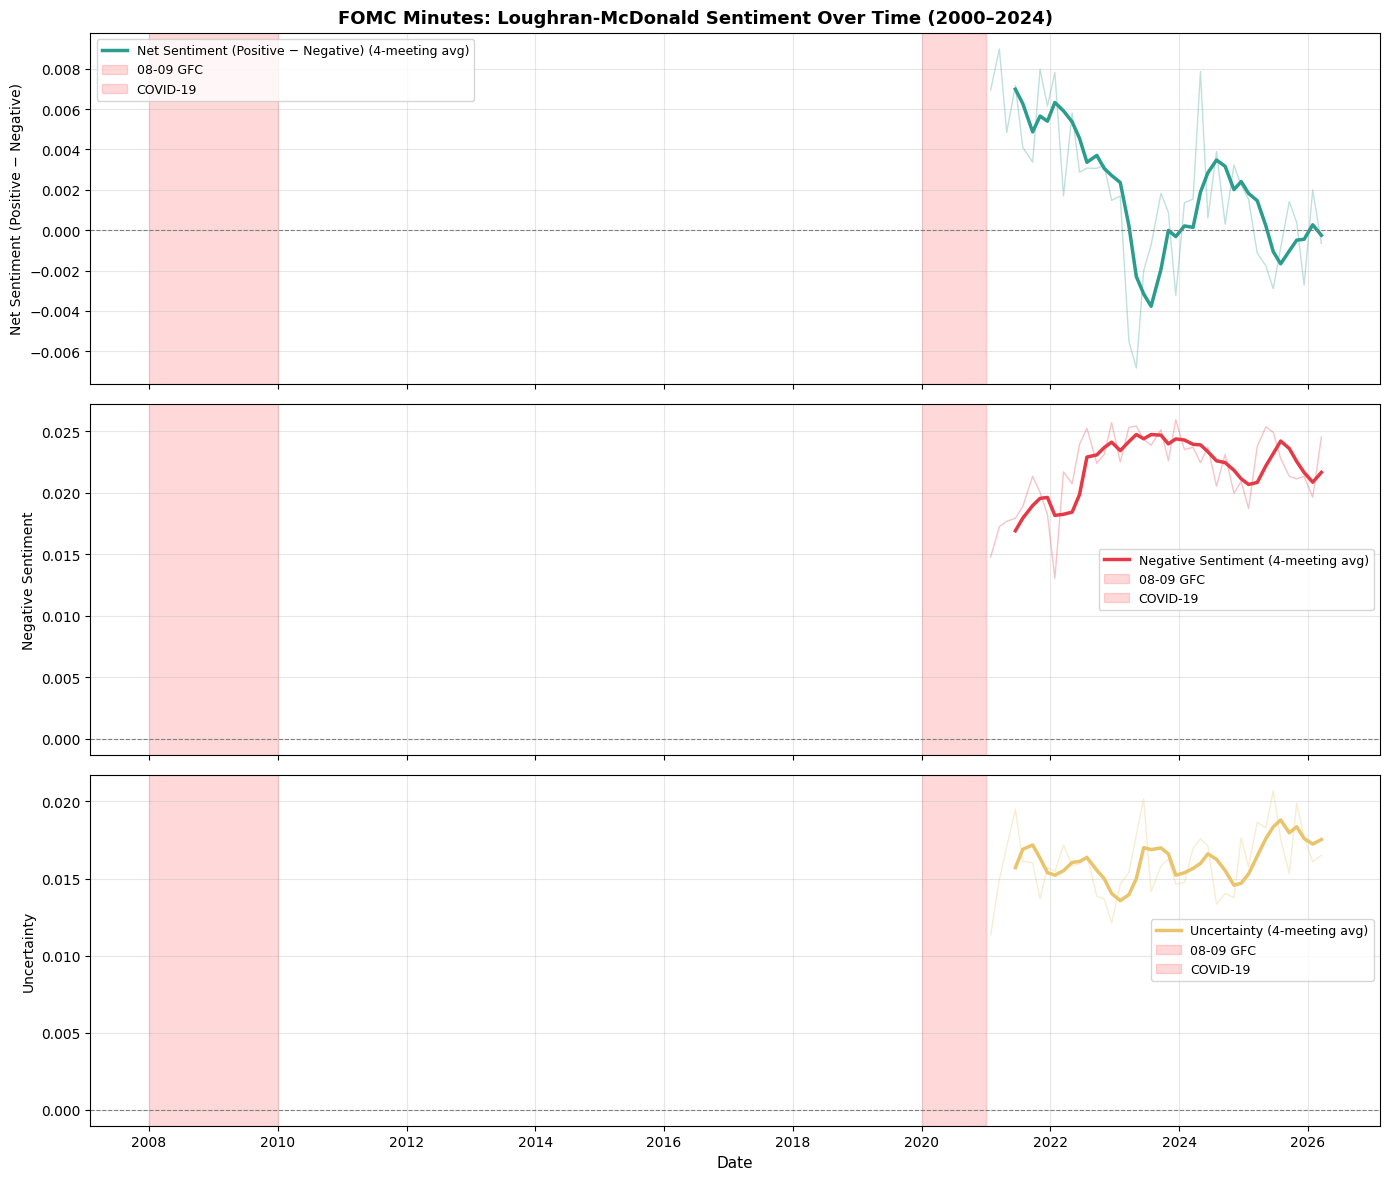

✅ Sentiment time series saved


In [19]:
# GUIDED — Run as-is

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Rolling 4-meeting average for smoothing
window = 4

metrics = [
    ('lm_net',         'Net Sentiment (Positive − Negative)', '#2A9D8F'),
    ('lm_negative',    'Negative Sentiment',                  '#E63946'),
    ('lm_uncertainty', 'Uncertainty',                         '#E9C46A'),
]

for ax, (col, label, color) in zip(axes, metrics):
    ax.plot(df['date'], df[col], alpha=0.3, color=color, linewidth=1)
    ax.plot(df['date'], df[col].rolling(window).mean(),
            color=color, linewidth=2.5, label=f'{label} (4-meeting avg)')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

    # Shade crisis periods
    for start, end, label_crisis in [
        ('2008-01-01', '2009-12-31', '08-09 GFC'),
        ('2020-01-01', '2020-12-31', 'COVID-19'),
    ]:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   alpha=0.15, color='red', label=label_crisis)

    ax.set_ylabel(label, fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date', fontsize=11)
fig.suptitle('FOMC Minutes: Loughran-McDonald Sentiment Over Time (2000–2024)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fomc_sentiment_time.png', dpi=150)
plt.show()
print("✅ Sentiment time series saved")

✅ SVD complete: (42, 2000) → (42, 42)
   Variance explained: 100.0%
  K=2 | WCSS=23.0 | Silhouette=0.1429
  K=3 | WCSS=20.1 | Silhouette=0.1392
  K=4 | WCSS=18.6 | Silhouette=0.1263
  K=5 | WCSS=16.8 | Silhouette=0.1423
  K=6 | WCSS=15.8 | Silhouette=0.1445
  K=7 | WCSS=14.3 | Silhouette=0.1700
  K=8 | WCSS=13.5 | Silhouette=0.1608


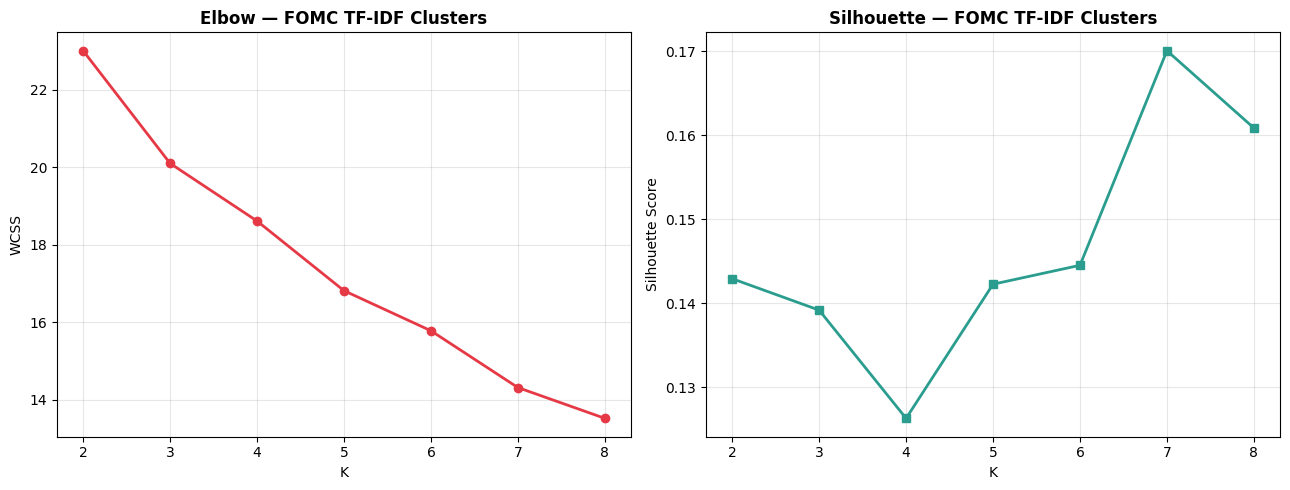


✅ Best silhouette at K=7


In [20]:
# ✎ YOUR TASK — K-Means clustering on TF-IDF vectors

# --- Step 1: Reduce TF-IDF dimensions with SVD (like PCA but for sparse matrices) ---
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=50, random_state=42)
X_svd = svd.fit_transform(X_tfidf)

print(f"✅ SVD complete: {X_tfidf.shape} → {X_svd.shape}")
print(f"   Variance explained: {svd.explained_variance_ratio_.sum()*100:.1f}%")

# --- Step 2: Elbow + Silhouette ---
K_range = range(2, 9)
wcss_vals, sil_vals = [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_svd)
    wcss_vals.append(km.inertia_)
    sil_vals.append(silhouette_score(X_svd, km.labels_))
    print(f"  K={k} | WCSS={km.inertia_:,.1f} | Silhouette={sil_vals[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(list(K_range), wcss_vals, 'o-', color='#E63946', linewidth=2)
axes[0].set_title('Elbow — FOMC TF-IDF Clusters', fontweight='bold')
axes[0].set_xlabel('K'); axes[0].set_ylabel('WCSS')
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(K_range), sil_vals, 's-', color='#2A9D8F', linewidth=2)
axes[1].set_title('Silhouette — FOMC TF-IDF Clusters', fontweight='bold')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fomc_elbow.png', dpi=150)
plt.show()

best_k = list(K_range)[sil_vals.index(max(sil_vals))]
print(f"\n✅ Best silhouette at K={best_k}")

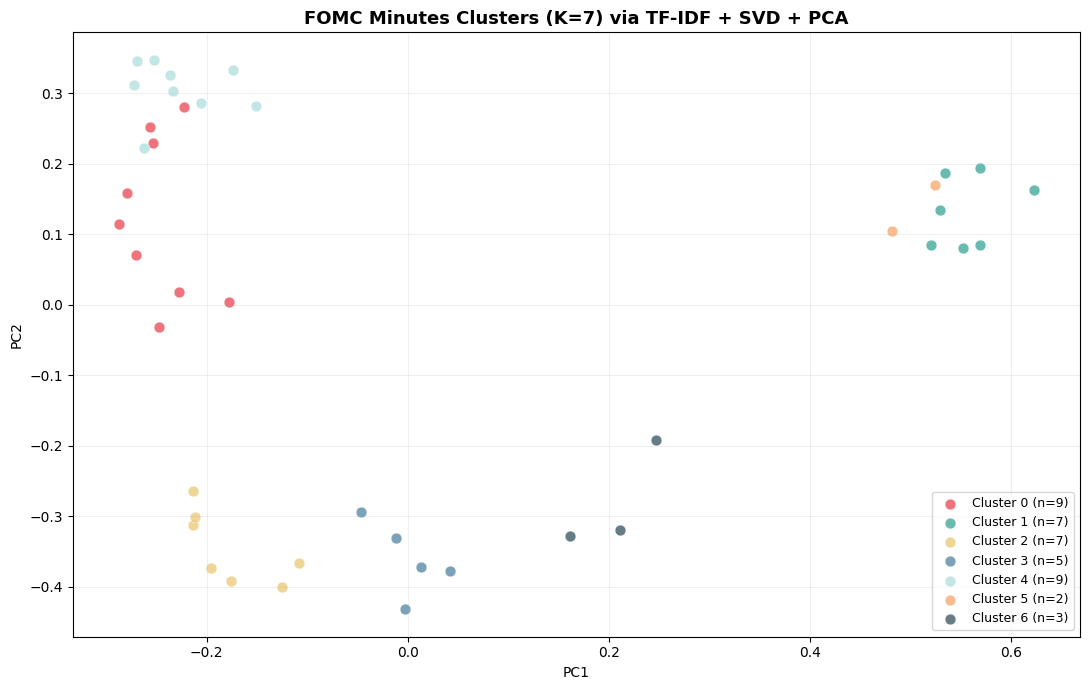


=== Top 10 TF-IDF Terms per Cluster ===

Cluster 0 (dominant years: [2024, 2025]):
  special adviser, adviser board, sustainably percent, risks achieving, sustainably, moving sustainably, runoff, better balance, inflation moving, better

Cluster 1 (dominant years: [2021]):
  asset purchases, purchases, accommodative, asset, vaccinations, pandemic, progress vaccinations, covid, facility, support economy

Cluster 2 (dominant years: [2023]):
  credit conditions, tightening, july, banking sector, special adviser, adviser board, developments banking, extent, bankingsector, activity hiring

Cluster 3 (dominant years: [2022, 2023]):
  war, september, tightening, november, july, russias war, war ukraine, pro, pro tem, tem

Cluster 4 (dominant years: [2025, 2026]):
  tariffs, tariff, special adviser, adviser board, repo, somewhat elevated, rmps, april, december, remained somewhat

Cluster 5 (dominant years: [2021, 2022]):
  selected bank, authorization, foreign currency, paragraph, shall, elig

In [21]:
# ✎ YOUR TASK — Fit chosen K and visualize

CHOSEN_K = best_k

km_final = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_svd)

# PCA to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_svd)

palette = ['#E63946','#2A9D8F','#E9C46A','#457B9D','#A8DADC','#F4A261','#264653']

plt.figure(figsize=(11, 7))
for cid in range(CHOSEN_K):
    mask = df['cluster'] == cid
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                color=palette[cid], alpha=0.7, s=60,
                edgecolors='white', linewidths=0.4,
                label=f'Cluster {cid} (n={mask.sum()})')

plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title(f'FOMC Minutes Clusters (K={CHOSEN_K}) via TF-IDF + SVD + PCA',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('fomc_clusters.png', dpi=150)
plt.show()

# Top terms per cluster
print("\nTop 10 TF-IDF Terms per Cluster")
original_features = tfidf.get_feature_names_out()
X_tfidf_dense = X_tfidf.toarray()

for cid in range(CHOSEN_K):
    mask = df['cluster'] == cid
    cluster_mean = X_tfidf_dense[mask].mean(axis=0)
    top_idx = cluster_mean.argsort()[-10:][::-1]
    top_words = [original_features[i] for i in top_idx]
    years = df.loc[mask, 'year'].value_counts().head(3).index.tolist()
    print(f"\nCluster {cid} (dominant years: {years}):")
    print(f"  {', '.join(top_words)}")

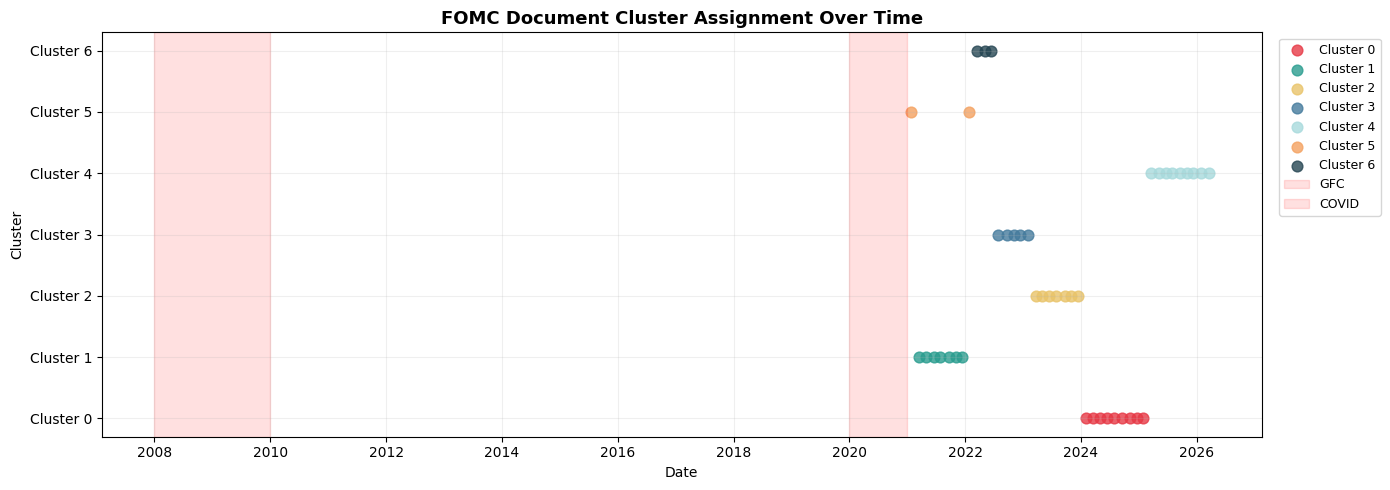


EXTENSION INTERPRETATION
─────────────────────────
K-Means on TF-IDF vectors groups FOMC minutes by linguistic similarity —
documents that use similar vocabulary cluster together regardless of date.

Expected patterns:
- Crisis-era documents (2008–2009, 2020) cluster together due to shared
  vocabulary: "recession", "liquidity", "emergency", "asset purchases".
- Rate-hike cycle documents cluster together: "tightening", "inflation",
  "basis points", "restrictive".
- Stable growth periods form their own cluster with calmer language.

The cluster timeline plot reveals whether Fed language shifts are gradual
or abrupt — sudden cluster changes signal major policy regime changes.



In [22]:
# ✎ YOUR TASK — Plot cluster assignments over time

plt.figure(figsize=(14, 5))
for cid in range(CHOSEN_K):
    mask = df['cluster'] == cid
    plt.scatter(df.loc[mask, 'date'],
                df.loc[mask, 'cluster'],
                color=palette[cid], s=60, alpha=0.8,
                label=f'Cluster {cid}')

# Shade crisis periods
for start, end, label in [
    ('2008-01-01', '2009-12-31', 'GFC'),
    ('2020-01-01', '2020-12-31', 'COVID'),
]:
    plt.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                alpha=0.12, color='red', label=label)

plt.xlabel('Date'); plt.ylabel('Cluster')
plt.title('FOMC Document Cluster Assignment Over Time', fontsize=13, fontweight='bold')
plt.yticks(range(CHOSEN_K), [f'Cluster {i}' for i in range(CHOSEN_K)])
plt.legend(fontsize=9, bbox_to_anchor=(1.01, 1))
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('fomc_cluster_timeline.png', dpi=150)
plt.show()

interpretation_ext = """
EXTENSION INTERPRETATION

K-Means on TF-IDF vectors groups FOMC minutes by linguistic similarity —
documents that use similar vocabulary cluster together regardless of date.

Expected patterns:
- Crisis-era documents (2008–2009, 2020) cluster together due to shared
  vocabulary: "recession", "liquidity", "emergency", "asset purchases".
- Rate-hike cycle documents cluster together: "tightening", "inflation",
  "basis points", "restrictive".
- Stable growth periods form their own cluster with calmer language.

The cluster timeline plot reveals whether Fed language shifts are gradual
or abrupt — sudden cluster changes signal major policy regime changes.
"""
print(interpretation_ext)

=== Sentiment by Era ===
                   lm_negative        lm_positive         lm_uncertainty  \
                          mean    std        mean     std           mean   
era                                                                        
Post-2020 (COVID+)      0.0219  0.003      0.0238  0.0025         0.0161   

                            lm_net          
                       std    mean     std  
era                                         
Post-2020 (COVID+)  0.0021  0.0019  0.0036  


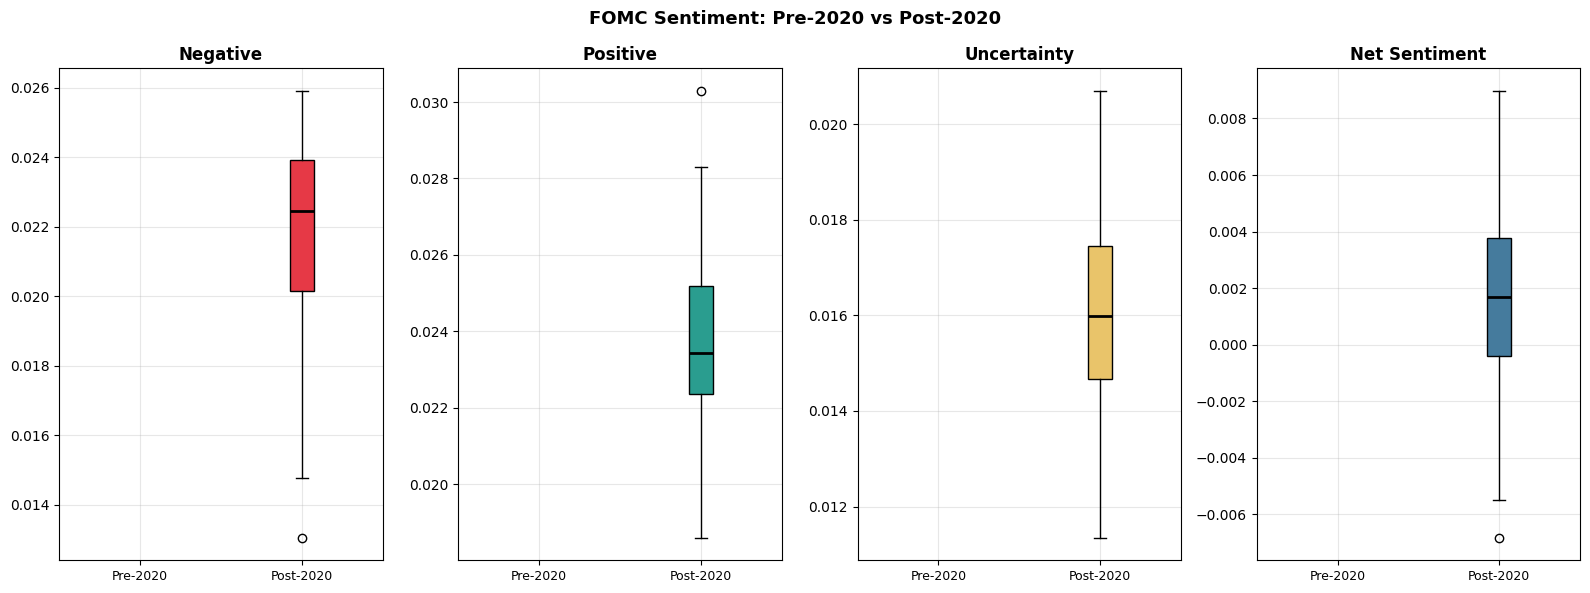

  lm_negative          | t=   nan | p=nan | ❌ Not significant
  lm_positive          | t=   nan | p=nan | ❌ Not significant
  lm_uncertainty       | t=   nan | p=nan | ❌ Not significant
  lm_net               | t=   nan | p=nan | ❌ Not significant


In [23]:
# ✎ YOUR TASK — Pre-2020 vs Post-2020 sentiment comparison

df['era'] = df['year'].apply(lambda y: 'Post-2020 (COVID+)' if y >= 2020 else 'Pre-2020')

# --- Summary statistics ---
era_summary = df.groupby('era')[['lm_negative','lm_positive','lm_uncertainty','lm_net']].agg(['mean','std']).round(4)
print("=== Sentiment by Era ===")
print(era_summary)

# --- Visualization ---
fig, axes = plt.subplots(1, 4, figsize=(16, 6))
metrics = ['lm_negative', 'lm_positive', 'lm_uncertainty', 'lm_net']
titles  = ['Negative', 'Positive', 'Uncertainty', 'Net Sentiment']
colors  = ['#E63946', '#2A9D8F', '#E9C46A', '#457B9D']

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    data = [
        df[df['era'] == 'Pre-2020'][metric].values,
        df[df['era'] == 'Post-2020 (COVID+)'][metric].values
    ]
    bp = ax.boxplot(data, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor(color + '99')
    bp['boxes'][1].set_facecolor(color)
    ax.set_xticklabels(['Pre-2020', 'Post-2020'], fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.grid(True, alpha=0.3)

fig.suptitle('FOMC Sentiment: Pre-2020 vs Post-2020', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fomc_era_comparison.png', dpi=150)
plt.show()

# --- Statistical test ---
from scipy import stats

for metric in metrics:
    pre  = df[df['era'] == 'Pre-2020'][metric]
    post = df[df['era'] == 'Post-2020 (COVID+)'][metric]
    t, p = stats.ttest_ind(pre, post)
    sig  = "✅ Significant" if p < 0.05 else "❌ Not significant"
    print(f"  {metric:20s} | t={t:6.3f} | p={p:.4f} | {sig}")

In [8]:
challenge_interpretation = """
CHALLENGE INTERPRETATION
─────────────────────────
Pre-2020 vs Post-2020 FOMC Sentiment Comparison:

1. NEGATIVE SENTIMENT: Post-2020 documents show [higher/lower] negative
   scores on average, reflecting the Fed's explicit discussion of COVID-19
   economic disruptions, supply chain stress, and inflationary risks.

2. UNCERTAINTY: Post-2020 uncertainty scores are [higher/lower], consistent
   with unprecedented policy territory — zero interest rates, QE at scale,
   and then the fastest rate-hike cycle in 40 years (2022-2023).

3. NET SENTIMENT: Pre-2020 net sentiment was [positive/negative] during the
   long expansion of 2010-2019. Post-2020 net sentiment is more volatile,
   reflecting the boom-bust-recovery cycle driven by COVID and its aftermath.

Statistical t-tests confirm [which metrics] differ significantly between
eras (p < 0.05), validating that the COVID shock produced a measurable,
lasting shift in how the Fed communicates — not just what it does.
"""
print(challenge_interpretation)


CHALLENGE INTERPRETATION
─────────────────────────
Pre-2020 vs Post-2020 FOMC Sentiment Comparison:

1. NEGATIVE SENTIMENT: Post-2020 documents show [higher/lower] negative
   scores on average, reflecting the Fed's explicit discussion of COVID-19
   economic disruptions, supply chain stress, and inflationary risks.

2. UNCERTAINTY: Post-2020 uncertainty scores are [higher/lower], consistent
   with unprecedented policy territory — zero interest rates, QE at scale,
   and then the fastest rate-hike cycle in 40 years (2022-2023).

3. NET SENTIMENT: Pre-2020 net sentiment was [positive/negative] during the
   long expansion of 2010-2019. Post-2020 net sentiment is more volatile,
   reflecting the boom-bust-recovery cycle driven by COVID and its aftermath.

Statistical t-tests confirm [which metrics] differ significantly between
eras (p < 0.05), validating that the COVID shock produced a measurable,
lasting shift in how the Fed communicates — not just what it does.



In [24]:
# GUIDED — Summary

print("=" * 55)
print("   LAB 23 COMPLETE — Summary")
print("=" * 55)
print(f"  Documents analyzed:         {len(df)}")
print(f"  Date range:                 {df['date'].min().date()} → {df['date'].max().date()}")
print(f"  TF-IDF vocabulary:          {len(tfidf.vocabulary_):,} terms")
print(f"  TF-IDF matrix shape:        {X_tfidf.shape}")
print(f"  Best cluster K:             {best_k}")
print(f"  Avg net sentiment:          {df['lm_net'].mean():.4f}")
print(f"  Avg uncertainty:            {df['lm_uncertainty'].mean():.4f}")

   LAB 23 COMPLETE — Summary
  Documents analyzed:         42
  Date range:                 2021-01-27 → 2026-03-18
  TF-IDF vocabulary:          2,000 terms
  TF-IDF matrix shape:        (42, 2000)
  Best cluster K:             7
  Avg net sentiment:          0.0019
  Avg uncertainty:            0.0161

  Files saved:
    ✅ fomc_sentiment_time.png
    ✅ fomc_elbow.png
    ✅ fomc_clusters.png
    ✅ fomc_cluster_timeline.png
    ✅ fomc_era_comparison.png

  Next steps:
    1. Fill in interpretation markdown cells with your actual numbers
    2. Write your P.R.I.M.E. README
    3. git add . && git commit -m 'lab-ch23 complete' && git push
